# 03 · Feature Engineering
### Dirección de Productos de Crédito — Minería de Datos UNAM

Transformación del dataset limpio en un conjunto de features listo para modelado.

---

### Mapa de transformaciones

| Sección | Transformación | Variables |
|---|---|---|
| F1 | Definición de variables objetivo (targets) | `TARGET_APROBADO`, `TARGET_PRODUCTO` |
| F2 | Flags binarios informativos | `FLAG_INGRESO_CERO`, `FLAG_SIN_SCORE_COMP`, `TIENE_TARJETAS`, `TIENE_LINEAS_REV` |
| F3 | Nuevas features por razones de negocio | Ratios financieros, score combinado, grupo de edad |
| F4 | Encoding ordinal | `SEGMENTO_ORD`, `ESCOLARIDAD_ORD`, `NIVEL_RIESGO_ORD`, `MESES_VENCIDOS_ORD`, `VIVIENDA_ORD` |
| F5 | Encoding binario | `CLIENTE_BANCO_BIN` |
| F6 | One-hot encoding | `COMPROBANTE_INGRESOS`, `TIPO_CTE` |
| F7 | Alerta de data leakage | Documentar variables que no pueden usarse en el modelo de aprobación |
| F8 | Normalización | StandardScaler y MinMaxScaler según tipo de variable |
| F9 | Datasets finales | `banco_features.csv` (completo) + subsets por modelo |

**Input:**  `data/processed/banco_clean.csv`
**Output:** `data/processed/banco_features.csv`


## 0 · Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib, os
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa", "axes.spines.top": False,
    "axes.spines.right": False, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.labelsize": 11,
})
RED, BLUE, GREEN, ORANGE = "#c0392b", "#2980b9", "#27ae60", "#e67e22"

SQ_G = "\033[32m■\033[0m"
SQ_R = "\033[31m■\033[0m"
SQ_B = "\033[34m■\033[0m"
SQ_Y = "\033[33m■\033[0m"

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.4f}".format)

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models",         exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

print(f"{SQ_G} Librerias cargadas")


■ Librerias cargadas


## 1 · Carga del dataset limpio

In [2]:
df = pd.read_csv("../data/processed/banco_clean.csv", encoding="utf-8")
print(f"Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print()

# Snapshot rapido
print("Columnas y tipos:")
for col in df.columns:
    print(f"  {col:<30} {str(df[col].dtype):<12} {df[col].nunique():>4} unicos")


Shape: 4,349 filas x 28 columnas

Columnas y tipos:
  NUM_SOLICITUD                  float64        11 unicos
  SUCURSAL                       int64         200 unicos
  STATUS_SOLICITUD               object          5 unicos
  PRODUCTO                       object          4 unicos
  APROBACION_TC                  object          3 unicos
  TIPO_CTE                       object          3 unicos
  LINEA_CREDITO_FINAL            float64       376 unicos
  CUENTA_ASIGNADA                float64         0 unicos
  MESES_VENCIDOS                 object          5 unicos
  SALDO_CUENTA                   float64      1040 unicos
  CAPACIDAD_TC                   float64       106 unicos
  INGRESO_INFERIDO               float64      1090 unicos
  COMPROBANTE_INGRESOS           object          4 unicos
  SEGMENTO_CLIENTE               object          5 unicos
  CLIENTE_CDE                    object          2 unicos
  SUMA_LINEAS_REVOLVENTES        int64         422 unicos
  NIVEL_RIESGO      

---
## F1 · Variables objetivo (targets)

El area de Productos de Credito tiene **dos preguntas de negocio** que dan lugar
a dos modelos distintos, cada uno con su propio target:

| Modelo | Pregunta | Target | Tipo |
|---|---|---|---|
| M1 — Aprobación | ¿Se aprobara la solicitud? | `TARGET_APROBADO` | Clasificacion binaria |
| M2 — Producto | ¿Que producto se asignara? | `TARGET_PRODUCTO` | Clasificacion multiclase |

### Decisiones de codificacion

**`TARGET_APROBADO`:** `PRE-APROBADO` se trata como aprobacion positiva (el banco
ya comprometio el credito, solo faltan formalismos).

**`TARGET_PRODUCTO`:** solo tiene sentido para solicitudes con producto asignado
(excluye `PRODUCTO = PENDIENTE`). Se usara en un subset del dataset.


In [3]:
print("=== F1: Variables objetivo ===")
print()

# TARGET_APROBADO
df["TARGET_APROBADO"] = df["APROBACION_TC"].map({
    "APROBADO"    : 1,
    "PRE-APROBADO": 1,
    "RECHAZADO"   : 0,
})
print(f"  TARGET_APROBADO:")
vc = df["TARGET_APROBADO"].value_counts()
for v, c in vc.items():
    etq = "Aprobado (1)" if v == 1 else "Rechazado (0)"
    pct = c / len(df) * 100
    bar = chr(9608) * int(pct / 2)
    print(f"    {etq:<18}  {c:>5,}  ({pct:.1f}%)  {bar}")

print()

# TARGET_PRODUCTO — solo para registros con producto asignado
mapa_producto = {"CLASICA": 0, "TARJETA_ORO": 1, "CREDITO_AUTO": 2}
df["TARGET_PRODUCTO"] = df["PRODUCTO"].map(mapa_producto)   # PENDIENTE queda NaN

print(f"  TARGET_PRODUCTO (solo solicitudes con producto asignado):")
vc2 = df["TARGET_PRODUCTO"].value_counts(dropna=False)
etqs = {0: "CLASICA (0)", 1: "TARJETA_ORO (1)", 2: "CREDITO_AUTO (2)"}
for v, c in vc2.items():
    etq = etqs.get(v, "PENDIENTE (NaN)")
    pct = c / len(df) * 100
    print(f"    {str(etq):<22}  {c:>5,}  ({pct:.1f}%)")

print()
sq = SQ_Y
print(f"  {sq}  Clase mayoritaria en TARGET_APROBADO: {vc.idxmax()} ({vc.max()/len(df)*100:.1f}%)")
print(f"  {sq}  Desbalance a considerar en el modelo de aprobacion")


=== F1: Variables objetivo ===

  TARGET_APROBADO:
    Rechazado (0)       2,712  (62.4%)  ███████████████████████████████
    Aprobado (1)        1,637  (37.6%)  ██████████████████

  TARGET_PRODUCTO (solo solicitudes con producto asignado):
    PENDIENTE (NaN)         2,712  (62.4%)
    CLASICA (0)             1,573  (36.2%)
    CREDITO_AUTO (2)           40  (0.9%)
    TARJETA_ORO (1)            24  (0.6%)

  ■  Clase mayoritaria en TARGET_APROBADO: 0 (62.4%)
  ■  Desbalance a considerar en el modelo de aprobacion


---
## F2 · Flags binarios informativos

Variables binarias que capturan **ausencia de informacion** como señal de negocio.
Un cliente con ingreso = 0 no necesariamente gana 0 — indica que el banco no pudo
inferirlo, lo cual es en si mismo un factor de riesgo.


In [4]:
print("=== F2: Flags binarios ===")
print()

# FLAG_INGRESO_CERO: ingreso no disponible
df["FLAG_INGRESO_CERO"] = (df["INGRESO_INFERIDO"] == 0).astype(int)
n = df["FLAG_INGRESO_CERO"].sum()
print(f"  {SQ_B}  FLAG_INGRESO_CERO         {n:>5,}  ({n/len(df)*100:.1f}%)  -> ingreso no disponible")

# FLAG_SIN_SCORE_COMP: sin historial de comportamiento
df["FLAG_SIN_SCORE_COMP"] = (df["SCORE_COMPORTAMIENTO"] == 0).astype(int)
n = df["FLAG_SIN_SCORE_COMP"].sum()
print(f"  {SQ_B}  FLAG_SIN_SCORE_COMP       {n:>5,}  ({n/len(df)*100:.1f}%)  -> sin historial en banco")

# TIENE_TARJETAS: ya tiene productos de credito en otro banco
df["TIENE_TARJETAS"] = (df["SUMA_SALDOS_TARJETAS"] > 0).astype(int)
n = df["TIENE_TARJETAS"].sum()
print(f"  {SQ_B}  TIENE_TARJETAS            {n:>5,}  ({n/len(df)*100:.1f}%)  -> tiene tarjetas activas")

# TIENE_LINEAS_REV: tiene lineas revolventes abiertas
df["TIENE_LINEAS_REV"] = (df["SUMA_LINEAS_REVOLVENTES"] > 0).astype(int)
n = df["TIENE_LINEAS_REV"].sum()
print(f"  {SQ_B}  TIENE_LINEAS_REV          {n:>5,}  ({n/len(df)*100:.1f}%)  -> tiene lineas revolventes")


=== F2: Flags binarios ===

  ■  FLAG_INGRESO_CERO         3,069  (70.6%)  -> ingreso no disponible
  ■  FLAG_SIN_SCORE_COMP       2,919  (67.1%)  -> sin historial en banco
  ■  TIENE_TARJETAS            1,139  (26.2%)  -> tiene tarjetas activas
  ■  TIENE_LINEAS_REV          1,034  (23.8%)  -> tiene lineas revolventes


---
## F3 · Nuevas features por razones de negocio

### Ratios financieros
Capturan relaciones entre variables que individualmente son menos informativas.  
Todos usan **division segura** (`safe_div`) para evitar errores por denominador = 0.

| Feature | Formula | Interpretacion de negocio |
|---|---|---|
| `RATIO_SALDO_LINEA` | SALDO_CUENTA / LINEA_CREDITO_FINAL | % de linea de credito utilizado |
| `RATIO_DEUDA_INGRESO` | SUMA_SALDOS_TARJETAS / INGRESO_INFERIDO | Carga de deuda relativa al ingreso |
| `RATIO_PAGO_INGRESO` | SUMA_PAGO_MIN_TARJETAS / INGRESO_INFERIDO | Compromiso de pago sobre ingreso |
| `RATIO_REVOLVENTE_INGRESO` | SUMA_LINEAS_REVOLVENTES / INGRESO_INFERIDO | Exposicion crediticia total |
| `SCORE_COMBINADO` | (SCORE_CLIENTE + SCORE_COMPORTAMIENTO) / 2 | Score unificado normalizado |
| `EDAD_GRUPO_ORD` | Bins de edad en 4 grupos | Segmentacion de ciclo de vida |


In [5]:
print("=== F3: Nuevas features de negocio ===")
print()

def safe_div(num, den, fill=0.0):
    """Division segura: devuelve fill cuando el denominador es 0."""
    with np.errstate(divide="ignore", invalid="ignore"):
        result = np.where(den != 0, num / den, fill)
    return result

# ── Ratios financieros ────────────────────────────────────────────────────────
df["RATIO_SALDO_LINEA"] = safe_div(
    df["SALDO_CUENTA"].values,
    df["LINEA_CREDITO_FINAL"].values
)
print(f"  {SQ_G}  RATIO_SALDO_LINEA          min={df['RATIO_SALDO_LINEA'].min():.3f}  max={df['RATIO_SALDO_LINEA'].max():.3f}  media={df['RATIO_SALDO_LINEA'].mean():.3f}")

df["RATIO_DEUDA_INGRESO"] = safe_div(
    df["SUMA_SALDOS_TARJETAS"].values,
    df["INGRESO_INFERIDO"].values
)
print(f"  {SQ_G}  RATIO_DEUDA_INGRESO        min={df['RATIO_DEUDA_INGRESO'].min():.3f}  max={df['RATIO_DEUDA_INGRESO'].max():.3f}  media={df['RATIO_DEUDA_INGRESO'].mean():.3f}")

df["RATIO_PAGO_INGRESO"] = safe_div(
    df["SUMA_PAGO_MIN_TARJETAS"].values,
    df["INGRESO_INFERIDO"].values
)
print(f"  {SQ_G}  RATIO_PAGO_INGRESO         min={df['RATIO_PAGO_INGRESO'].min():.3f}  max={df['RATIO_PAGO_INGRESO'].max():.3f}  media={df['RATIO_PAGO_INGRESO'].mean():.3f}")

df["RATIO_REVOLVENTE_INGRESO"] = safe_div(
    df["SUMA_LINEAS_REVOLVENTES"].values,
    df["INGRESO_INFERIDO"].values
)
print(f"  {SQ_G}  RATIO_REVOLVENTE_INGRESO   min={df['RATIO_REVOLVENTE_INGRESO'].min():.3f}  max={df['RATIO_REVOLVENTE_INGRESO'].max():.3f}  media={df['RATIO_REVOLVENTE_INGRESO'].mean():.3f}")

# ── Score combinado ───────────────────────────────────────────────────────────
# Normalizar cada score a [0,1] antes de promediar (escalas muy distintas)
sc_min, sc_max = df["SCORE_CLIENTE"].min(),        df["SCORE_CLIENTE"].max()
sb_min, sb_max = df["SCORE_COMPORTAMIENTO"].min(), df["SCORE_COMPORTAMIENTO"].max()

score_c_norm = (df["SCORE_CLIENTE"]        - sc_min) / (sc_max - sc_min)
score_b_norm = (df["SCORE_COMPORTAMIENTO"] - sb_min) / (sb_max - sb_min)
df["SCORE_COMBINADO"] = (score_c_norm + score_b_norm) / 2
print(f"  {SQ_G}  SCORE_COMBINADO            min={df['SCORE_COMBINADO'].min():.3f}  max={df['SCORE_COMBINADO'].max():.3f}  media={df['SCORE_COMBINADO'].mean():.3f}")
print(f"       (SCORE_CLIENTE [89-297] y SCORE_COMPORTAMIENTO [0-805] normalizados antes de combinar)")

# ── Grupo de edad ─────────────────────────────────────────────────────────────
bins   = [24, 34, 44, 54, 61]
labels = [0, 1, 2, 3]   # Joven / Adulto / Maduro / Senior
etqs   = {0: "Joven (25-34)", 1: "Adulto (35-44)", 2: "Maduro (45-54)", 3: "Senior (55-60)"}
df["EDAD_GRUPO_ORD"] = pd.cut(df["EDAD"], bins=bins, labels=labels).astype(int)

print(f"\n  {SQ_G}  EDAD_GRUPO_ORD:")
for v, etq in etqs.items():
    c = (df["EDAD_GRUPO_ORD"] == v).sum()
    pct = c / len(df) * 100
    print(f"       {v} = {etq:<20}  {c:>5,}  ({pct:.1f}%)")


=== F3: Nuevas features de negocio ===

  ■  RATIO_SALDO_LINEA          min=-0.200  max=2.421  media=0.201
  ■  RATIO_DEUDA_INGRESO        min=0.000  max=5.040  media=0.069
  ■  RATIO_PAGO_INGRESO         min=0.000  max=1.650  media=0.004
  ■  RATIO_REVOLVENTE_INGRESO   min=0.000  max=28.607  media=0.302
  ■  SCORE_COMBINADO            min=0.000  max=0.960  media=0.271
       (SCORE_CLIENTE [89-297] y SCORE_COMPORTAMIENTO [0-805] normalizados antes de combinar)

  ■  EDAD_GRUPO_ORD:
       0 = Joven (25-34)         1,177  (27.1%)
       1 = Adulto (35-44)        1,207  (27.8%)
       2 = Maduro (45-54)        1,242  (28.6%)
       3 = Senior (55-60)          723  (16.6%)


In [ ]:
# ── Distribucion de ratios financieros ───────────────────────────────────────
ratios = ["RATIO_SALDO_LINEA", "RATIO_DEUDA_INGRESO",
          "RATIO_PAGO_INGRESO", "RATIO_REVOLVENTE_INGRESO", "SCORE_COMBINADO"]

fig, axes = plt.subplots(1, len(ratios), figsize=(16, 4))
for ax, col in zip(axes, ratios):
    data = df[col]
    ax.hist(data, bins=40, color=BLUE, alpha=0.75, edgecolor="white")
    ax.axvline(data.mean(),   color=RED,   linestyle="--", lw=1.5,
               label=f"Media {data.mean():.2f}")
    ax.axvline(data.median(), color=GREEN, linestyle=":",  lw=1.5,
               label=f"Mediana {data.median():.2f}")
    ax.set_title(col.replace("_"," "), fontweight="bold", fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Distribución de nuevas features de negocio", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/03_ratios_financieros.png", bbox_inches="tight")
plt.show()


---
## F4 · Encoding ordinal

Variables categoricas con **orden natural definido**. Se asigna un entero
que preserva la relacion de mayor a menor.

| Variable | Orden | Logica |
|---|---|---|
| `SEGMENTO_ORD` | BAJO_B < MEDIO_B < MEDIO_A < ALTO_B < ALTO_A | Nivel socioeconomico creciente |
| `ESCOLARIDAD_ORD` | PRIMARIA < SECUNDARIA < PREPARATORIA < LICENCIATURA < POSGRADO | Nivel academico creciente |
| `NIVEL_RIESGO_ORD` | BAJO < MEDIO < ALTO | Riesgo creciente |
| `MESES_VENCIDOS_ORD` | SIN_CUENTA < 0 < 1 < 2 < 3 | Morosidad creciente |
| `VIVIENDA_ORD` | FAMILIARES < RENTA < HIPOTECA < PROPIA | Estabilidad patrimonial creciente |


In [6]:
print("=== F4: Encoding ordinal ===")
print()

# SEGMENTO
mapa_seg = {"BAJO_B": 0, "MEDIO_B": 1, "MEDIO_A": 2, "ALTO_B": 3, "ALTO_A": 4}
df["SEGMENTO_ORD"] = df["SEGMENTO_CLIENTE"].map(mapa_seg)
print(f"  {SQ_G}  SEGMENTO_ORD        {df['SEGMENTO_ORD'].value_counts().sort_index().to_dict()}")

# ESCOLARIDAD
mapa_esc = {"PRIMARIA": 0, "SECUNDARIA": 1, "PREPARATORIA": 2,
            "LICENCIATURA": 3, "POSGRADO": 4}
df["ESCOLARIDAD_ORD"] = df["ESCOLARIDAD"].map(mapa_esc)
print(f"  {SQ_G}  ESCOLARIDAD_ORD     {df['ESCOLARIDAD_ORD'].value_counts().sort_index().to_dict()}")

# NIVEL RIESGO
mapa_riesgo = {"BAJO": 0, "MEDIO": 1, "ALTO": 2}
df["NIVEL_RIESGO_ORD"] = df["NIVEL_RIESGO"].map(mapa_riesgo)
print(f"  {SQ_G}  NIVEL_RIESGO_ORD    {df['NIVEL_RIESGO_ORD'].value_counts().sort_index().to_dict()}")

# MESES VENCIDOS
mapa_mv = {"SIN_CUENTA": 0, "0": 1, "1": 2, "2": 3, "3": 4}
df["MESES_VENCIDOS_ORD"] = df["MESES_VENCIDOS"].map(mapa_mv)
print(f"  {SQ_G}  MESES_VENCIDOS_ORD  {df['MESES_VENCIDOS_ORD'].value_counts().sort_index().to_dict()}")

# TIPO VIVIENDA
mapa_viv = {"FAMILIARES": 0, "RENTA": 1, "HIPOTECA": 2, "PROPIA": 3}
df["VIVIENDA_ORD"] = df["TIPO_VIVIENDA"].map(mapa_viv)
print(f"  {SQ_G}  VIVIENDA_ORD        {df['VIVIENDA_ORD'].value_counts().sort_index().to_dict()}")

# Verificar nulos generados por el mapeo
nulos_ord = ["SEGMENTO_ORD","ESCOLARIDAD_ORD","NIVEL_RIESGO_ORD",
             "MESES_VENCIDOS_ORD","VIVIENDA_ORD"]
print()
for col in nulos_ord:
    n = df[col].isnull().sum()
    sq = SQ_G if n == 0 else SQ_R
    print(f"  {sq}  {col:<25} nulos: {n}")


=== F4: Encoding ordinal ===

  ■  SEGMENTO_ORD        {0: 73, 1: 1101, 2: 1714, 3: 972, 4: 489}
  ■  ESCOLARIDAD_ORD     {1: 58, 2: 1355, 3: 1527, 4: 1409}
  ■  NIVEL_RIESGO_ORD    {0: 1265, 1: 135, 2: 2949}
  ■  MESES_VENCIDOS_ORD  {0: 2368, 1: 888, 2: 701, 3: 358, 4: 34}
  ■  VIVIENDA_ORD        {0: 1051, 1: 1003, 2: 1271, 3: 1024}

  ■  SEGMENTO_ORD              nulos: 0
  ■  ESCOLARIDAD_ORD           nulos: 0
  ■  NIVEL_RIESGO_ORD          nulos: 0
  ■  MESES_VENCIDOS_ORD        nulos: 0
  ■  VIVIENDA_ORD              nulos: 0


---
## F5 · Encoding binario

`CLIENTE_CDE` tiene exactamente dos valores — se convierte directamente a 0/1.


In [7]:
print("=== F5: Encoding binario ===")
print()

df["CLIENTE_BANCO_BIN"] = (df["CLIENTE_CDE"] == "CLIENTE_BANCO").astype(int)
vc = df["CLIENTE_BANCO_BIN"].value_counts()
print(f"  {SQ_G}  CLIENTE_BANCO_BIN = 1 (cliente banco) : {vc.get(1,0):>5,}  ({vc.get(1,0)/len(df)*100:.1f}%)")
print(f"  {SQ_G}  CLIENTE_BANCO_BIN = 0 (no cliente)    : {vc.get(0,0):>5,}  ({vc.get(0,0)/len(df)*100:.1f}%)")


=== F5: Encoding binario ===

  ■  CLIENTE_BANCO_BIN = 1 (cliente banco) : 1,092  (25.1%)
  ■  CLIENTE_BANCO_BIN = 0 (no cliente)    : 3,257  (74.9%)


---
## F6 · One-hot encoding

Variables nominales sin orden natural: `COMPROBANTE_INGRESOS` y `TIPO_CTE`.

Se usa `drop_first=False` para conservar todas las categorias (interpretabilidad).  
`PRODUCTO`, `STATUS_SOLICITUD` y `APROBACION_TC` **no se encodean aqui** porque
son los targets o estan directamente relacionados (riesgo de leakage — ver F7).


In [8]:
print("=== F6: One-hot encoding ===")
print()

cols_ohe = ["COMPROBANTE_INGRESOS", "TIPO_CTE"]

for col in cols_ohe:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False, dtype=int)
    df = pd.concat([df, dummies], axis=1)
    cols_gen = dummies.columns.tolist()
    print(f"  {SQ_G}  {col}  ->  {cols_gen}")

print()
print(f"  Shape despues de OHE: {df.shape}")


=== F6: One-hot encoding ===

  ■  COMPROBANTE_INGRESOS  ->  ['COMPROBANTE_INGRESOS_DECLARACION ANUAL', 'COMPROBANTE_INGRESOS_INVERSIONES', 'COMPROBANTE_INGRESOS_RECIBO DE NOMINA', 'COMPROBANTE_INGRESOS_SIN COMPROBANTE']
  ■  TIPO_CTE  ->  ['TIPO_CTE_BUENO', 'TIPO_CTE_MALO', 'TIPO_CTE_REGULAR']

  Shape despues de OHE: (4349, 53)


---
## F7 · Alerta de data leakage

Esta seccion documenta variables que **no pueden usarse como features** en el
modelo de aprobacion (M1), porque su valor solo existe *despues* de que se
toma la decision de aprobar.

Incluirlas seria informar al modelo con informacion del futuro — el modelo
aprenderia a hacer trampa en lugar de generalizar.

| Variable | Por que es leakage en M1 | Uso permitido |
|---|---|---|
| `SALDO_CUENTA` | Solo existe si hay cuenta activa (post-aprobacion) | M2 producto, analisis descriptivo |
| `CAPACIDAD_TC` | Idem | M2, descriptivo |
| `MESES_VENCIDOS_ORD` | Solo existe si hay cuenta activa | M2, descriptivo |
| `TIENE_CUENTA` | Es practicamente identico al target | Ninguno como feature |
| `LINEA_CREDITO_FINAL` | Se define al aprobar | M2, descriptivo |
| `RATIO_SALDO_LINEA` | Depende de SALDO y LINEA post-aprobacion | M2, descriptivo |
| `STATUS_SOLICITUD` | Coincide casi perfecto con TARGET_APROBADO | Ninguno como feature |
| `APROBACION_TC` | ES el target | Solo como target |


In [9]:
print("=== F7: Variables con riesgo de leakage ===")
print()

LEAKAGE_M1 = [
    "SALDO_CUENTA", "CAPACIDAD_TC", "MESES_VENCIDOS", "MESES_VENCIDOS_ORD",
    "TIENE_CUENTA", "LINEA_CREDITO_FINAL", "RATIO_SALDO_LINEA",
    "STATUS_SOLICITUD", "APROBACION_TC",
]

print("  Variables EXCLUIDAS del modelo de aprobacion (M1):")
for v in LEAKAGE_M1:
    print(f"  {SQ_R}  {v}")

print()
print(f"  {SQ_Y}  Estas variables SI pueden usarse en analisis descriptivo")
print(f"  {SQ_Y}  y en el modelo de producto (M2, que corre solo sobre aprobados)")

# Verificar correlacion de STATUS con TARGET para ilustrar el leakage
from scipy.stats import pointbiserialr
status_bin = (df["STATUS_SOLICITUD"] == "APROBADA").astype(int)
r, p = pointbiserialr(status_bin, df["TARGET_APROBADO"])
print()
print(f"  Correlacion STATUS_APROBADA vs TARGET_APROBADO: r = {r:.4f}  (p = {p:.2e})")
print(f"  {SQ_R}  Correlacion casi perfecta — confirma el leakage")


=== F7: Variables con riesgo de leakage ===

  Variables EXCLUIDAS del modelo de aprobacion (M1):
  ■  SALDO_CUENTA
  ■  CAPACIDAD_TC
  ■  MESES_VENCIDOS
  ■  MESES_VENCIDOS_ORD
  ■  TIENE_CUENTA
  ■  LINEA_CREDITO_FINAL
  ■  RATIO_SALDO_LINEA
  ■  STATUS_SOLICITUD
  ■  APROBACION_TC

  ■  Estas variables SI pueden usarse en analisis descriptivo
  ■  y en el modelo de producto (M2, que corre solo sobre aprobados)

  Correlacion STATUS_APROBADA vs TARGET_APROBADO: r = 0.9009  (p = 0.00e+00)
  ■  Correlacion casi perfecta — confirma el leakage


---
## F8 · Normalizacion

### Criterio de seleccion de scaler

| Scaler | Cuando usarlo | Variables |
|---|---|---|
| `StandardScaler` | Variables con distribucion aproximadamente normal o simetrica | Scores, sumas, solicitudes rechazadas |
| `MinMaxScaler` | Variables con rango acotado y conocido | Edad, capacidades (%), ratios [0-1] |

Las variables que ya estan en [0,1] (`SCORE_COMBINADO`, flags binarios) no se escalan.  
Los encodings ordinales tampoco — sus valores enteros ya son comparables entre si.

Los scalers se guardan en `models/` para aplicarlos identicamente en produccion.


In [10]:
print("=== F8: Normalizacion ===")
print()

COLS_STANDARD = [
    "SCORE_CLIENTE", "SCORE_COMPORTAMIENTO",
    "SUMA_LINEAS_REVOLVENTES", "SUMA_SALDOS_TARJETAS", "SUMA_PAGO_MIN_TARJETAS",
    "SOLICITUDES_RECHAZADAS", "INGRESO_INFERIDO",
    "RATIO_DEUDA_INGRESO", "RATIO_PAGO_INGRESO", "RATIO_REVOLVENTE_INGRESO",
]

COLS_MINMAX = [
    "EDAD", "CAPACIDAD_PAGO_TOTAL", "CAPACIDAD_TC",
]

# ── StandardScaler ─────────────────────────────────────────────────────────
scaler_std = StandardScaler()
df_std = df[COLS_STANDARD].copy()
scaled_std = scaler_std.fit_transform(df_std)
scaled_std_df = pd.DataFrame(scaled_std,
                              columns=[c + "_STD" for c in COLS_STANDARD],
                              index=df.index)
df = pd.concat([df, scaled_std_df], axis=1)

print(f"  {SQ_G}  StandardScaler aplicado a {len(COLS_STANDARD)} variables:")
for col in COLS_STANDARD:
    col_s = col + "_STD"
    print(f"       {col_s:<40} media={df[col_s].mean():.4f}  std={df[col_s].std():.4f}")

# ── MinMaxScaler ───────────────────────────────────────────────────────────
print()
scaler_mm = MinMaxScaler()
df_mm = df[COLS_MINMAX].copy()
scaled_mm = scaler_mm.fit_transform(df_mm)
scaled_mm_df = pd.DataFrame(scaled_mm,
                             columns=[c + "_MM" for c in COLS_MINMAX],
                             index=df.index)
df = pd.concat([df, scaled_mm_df], axis=1)

print(f"  {SQ_G}  MinMaxScaler aplicado a {len(COLS_MINMAX)} variables:")
for col in COLS_MINMAX:
    col_m = col + "_MM"
    print(f"       {col_m:<40} min={df[col_m].min():.4f}  max={df[col_m].max():.4f}")

# ── Guardar scalers ────────────────────────────────────────────────────────
joblib.dump(scaler_std, "../models/scaler_standard.pkl")
joblib.dump(scaler_mm,  "../models/scaler_minmax.pkl")
print()
print(f"  {SQ_G}  Scalers guardados en ../models/")
print(f"       scaler_standard.pkl  ->  {COLS_STANDARD}")
print(f"       scaler_minmax.pkl    ->  {COLS_MINMAX}")


=== F8: Normalizacion ===

  ■  StandardScaler aplicado a 10 variables:
       SCORE_CLIENTE_STD                        media=-0.0000  std=1.0001
       SCORE_COMPORTAMIENTO_STD                 media=-0.0000  std=1.0001
       SUMA_LINEAS_REVOLVENTES_STD              media=0.0000  std=1.0001
       SUMA_SALDOS_TARJETAS_STD                 media=-0.0000  std=1.0001
       SUMA_PAGO_MIN_TARJETAS_STD               media=-0.0000  std=1.0001
       SOLICITUDES_RECHAZADAS_STD               media=0.0000  std=1.0001
       INGRESO_INFERIDO_STD                     media=-0.0000  std=1.0001
       RATIO_DEUDA_INGRESO_STD                  media=0.0000  std=1.0001
       RATIO_PAGO_INGRESO_STD                   media=-0.0000  std=1.0001
       RATIO_REVOLVENTE_INGRESO_STD             media=0.0000  std=1.0001

  ■  MinMaxScaler aplicado a 3 variables:
       EDAD_MM                                  min=0.0000  max=1.0000
       CAPACIDAD_PAGO_TOTAL_MM                  min=0.0000  max=1.0000
       

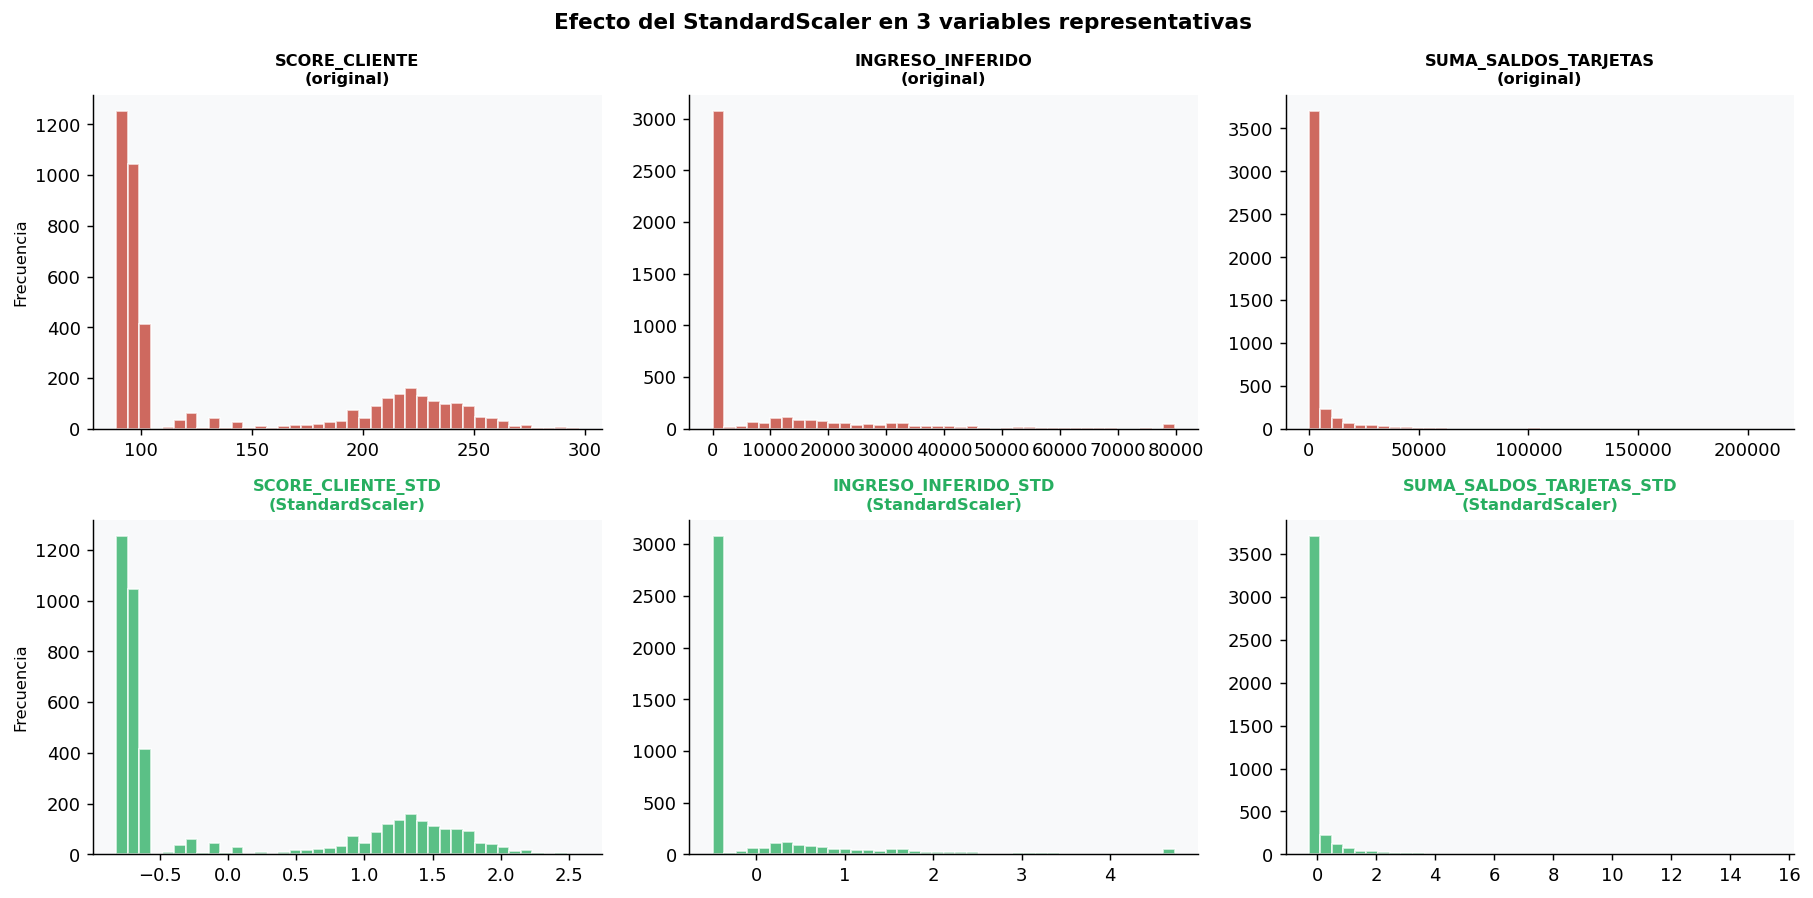

In [11]:
# ── Comparacion antes / despues de escalar ──────────────────────────────────
cols_vis = ["SCORE_CLIENTE", "INGRESO_INFERIDO", "SUMA_SALDOS_TARJETAS"]
fig, axes = plt.subplots(2, len(cols_vis), figsize=(14, 7))

for i, col in enumerate(cols_vis):
    col_s = col + "_STD"

    # Antes
    axes[0][i].hist(df[col],   bins=40, color=RED,   alpha=0.75, edgecolor="white")
    axes[0][i].set_title(f"{col}\n(original)", fontweight="bold", fontsize=9)
    if i == 0: axes[0][i].set_ylabel("Frecuencia", fontsize=9)

    # Despues
    axes[1][i].hist(df[col_s], bins=40, color=GREEN, alpha=0.75, edgecolor="white")
    axes[1][i].set_title(f"{col_s}\n(StandardScaler)", fontweight="bold",
                          fontsize=9, color=GREEN)
    if i == 0: axes[1][i].set_ylabel("Frecuencia", fontsize=9)

plt.suptitle("Efecto del StandardScaler en 3 variables representativas",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/03_scaling_comparacion.png", bbox_inches="tight")
plt.show()


---
## F9 · Datasets finales por modelo

Se generan tres archivos:

| Archivo | Descripcion | Filas |
|---|---|---|
| `banco_features.csv` | Dataset completo con todas las features | 4,349 |
| `features_modelo_aprobacion.csv` | Solo features validas para M1 (sin leakage) | 4,349 |
| `features_modelo_producto.csv` | Solo solicitudes con producto asignado, para M2 | ~1,640 |


In [12]:
print("=== F9: Generacion de datasets finales ===")
print()

# Columnas raw originales (se conservan para trazabilidad)
COLS_RAW_EXCLUIR = ["NUM_SOLICITUD", "CUENTA_ASIGNADA"]

# ── 1. Dataset completo con todas las features ──────────────────────────────
df_full = df.drop(columns=COLS_RAW_EXCLUIR)
df_full.to_csv("../data/processed/banco_features.csv", index=False, encoding="utf-8")
print(f"  {SQ_G}  banco_features.csv          shape: {df_full.shape}")

# ── 2. Features para modelo de aprobacion (M1) — sin leakage ───────────────
LEAKAGE_M1 = [
    "SALDO_CUENTA", "CAPACIDAD_TC", "MESES_VENCIDOS", "MESES_VENCIDOS_ORD",
    "TIENE_CUENTA", "LINEA_CREDITO_FINAL", "RATIO_SALDO_LINEA",
    "STATUS_SOLICITUD", "APROBACION_TC", "TARGET_PRODUCTO",
    # Versiones escaladas de leakage
    "CAPACIDAD_TC_MM",
]

# Features finales M1: numericas scaled + ordinales + flags + OHE + target
FEATURES_M1 = [c for c in df_full.columns
               if c not in LEAKAGE_M1
               and c not in ["SEGMENTO_CLIENTE","ESCOLARIDAD","NIVEL_RIESGO",
                              "TIPO_VIVIENDA","CLIENTE_CDE","TIPO_CTE",
                              "COMPROBANTE_INGRESOS","PRODUCTO",
                              # no usar raw si ya existe STD o MM
                              "SCORE_CLIENTE","SCORE_COMPORTAMIENTO",
                              "SUMA_LINEAS_REVOLVENTES","SUMA_SALDOS_TARJETAS",
                              "SUMA_PAGO_MIN_TARJETAS","SOLICITUDES_RECHAZADAS",
                              "INGRESO_INFERIDO","RATIO_DEUDA_INGRESO",
                              "RATIO_PAGO_INGRESO","RATIO_REVOLVENTE_INGRESO",
                              "EDAD","CAPACIDAD_PAGO_TOTAL",
                              ]]

df_m1 = df_full[FEATURES_M1]
df_m1.to_csv("../data/processed/features_modelo_aprobacion.csv", index=False, encoding="utf-8")
print(f"  {SQ_G}  features_modelo_aprobacion.csv  shape: {df_m1.shape}")

# ── 3. Features para modelo de producto (M2) — solo aprobados con producto ──
mask_m2 = df_full["TARGET_PRODUCTO"].notna()
FEATURES_M2 = [c for c in df_full.columns
               if c not in ["STATUS_SOLICITUD","APROBACION_TC","TARGET_APROBADO",
                             "PRODUCTO","SEGMENTO_CLIENTE","ESCOLARIDAD",
                             "NIVEL_RIESGO","TIPO_VIVIENDA","CLIENTE_CDE",
                             "TIPO_CTE","COMPROBANTE_INGRESOS",
                             "SCORE_CLIENTE","SCORE_COMPORTAMIENTO",
                             "SUMA_LINEAS_REVOLVENTES","SUMA_SALDOS_TARJETAS",
                             "SUMA_PAGO_MIN_TARJETAS","SOLICITUDES_RECHAZADAS",
                             "INGRESO_INFERIDO","RATIO_DEUDA_INGRESO",
                             "RATIO_PAGO_INGRESO","RATIO_REVOLVENTE_INGRESO",
                             "EDAD","CAPACIDAD_PAGO_TOTAL","CAPACIDAD_TC",
                             ]]
df_m2 = df_full.loc[mask_m2, FEATURES_M2]
df_m2.to_csv("../data/processed/features_modelo_producto.csv", index=False, encoding="utf-8")
print(f"  {SQ_G}  features_modelo_producto.csv    shape: {df_m2.shape}")


=== F9: Generacion de datasets finales ===

  ■  banco_features.csv          shape: (4349, 64)
  ■  features_modelo_aprobacion.csv  shape: (4349, 33)
  ■  features_modelo_producto.csv    shape: (1637, 40)


In [13]:
print()
print("Resumen de features por dataset:")
print()

def mostrar_features(df_in, nombre):
    print(f"  {nombre}  ({df_in.shape[1]} columnas):")
    cats = {"target": [], "flag": [], "ordinal": [], "ohe": [],
            "scaled_std": [], "scaled_mm": [], "ratio": [], "otro": []}
    for c in df_in.columns:
        if "TARGET" in c:          cats["target"].append(c)
        elif "FLAG" in c or c in ["TIENE_TARJETAS","TIENE_LINEAS_REV",
                                   "CLIENTE_BANCO_BIN","TIENE_CUENTA"]: cats["flag"].append(c)
        elif c.endswith("_ORD"):   cats["ordinal"].append(c)
        elif c.endswith("_STD"):   cats["scaled_std"].append(c)
        elif c.endswith("_MM"):    cats["scaled_mm"].append(c)
        elif "RATIO" in c or "SCORE_COMBINADO" in c or "EDAD_GRUPO" in c: cats["ratio"].append(c)
        elif any(p in c for p in ["COMPROBANTE","TIPO_CTE"]): cats["ohe"].append(c)
        else:                      cats["otro"].append(c)
    for tipo, cols in cats.items():
        if cols:
            print(f"    [{tipo.upper()}]  {cols}")
    print()

mostrar_features(df_m1, "M1 — Aprobacion")
mostrar_features(df_m2, "M2 — Producto")



Resumen de features por dataset:

  M1 — Aprobacion  (33 columnas):
    [TARGET]  ['TARGET_APROBADO']
    [FLAG]  ['FLAG_INGRESO_CERO', 'FLAG_SIN_SCORE_COMP', 'TIENE_TARJETAS', 'TIENE_LINEAS_REV', 'CLIENTE_BANCO_BIN']
    [ORDINAL]  ['EDAD_GRUPO_ORD', 'SEGMENTO_ORD', 'ESCOLARIDAD_ORD', 'NIVEL_RIESGO_ORD', 'VIVIENDA_ORD']
    [OHE]  ['COMPROBANTE_INGRESOS_DECLARACION ANUAL', 'COMPROBANTE_INGRESOS_INVERSIONES', 'COMPROBANTE_INGRESOS_RECIBO DE NOMINA', 'COMPROBANTE_INGRESOS_SIN COMPROBANTE', 'TIPO_CTE_BUENO', 'TIPO_CTE_MALO', 'TIPO_CTE_REGULAR']
    [SCALED_STD]  ['SCORE_CLIENTE_STD', 'SCORE_COMPORTAMIENTO_STD', 'SUMA_LINEAS_REVOLVENTES_STD', 'SUMA_SALDOS_TARJETAS_STD', 'SUMA_PAGO_MIN_TARJETAS_STD', 'SOLICITUDES_RECHAZADAS_STD', 'INGRESO_INFERIDO_STD', 'RATIO_DEUDA_INGRESO_STD', 'RATIO_PAGO_INGRESO_STD', 'RATIO_REVOLVENTE_INGRESO_STD']
    [SCALED_MM]  ['EDAD_MM', 'CAPACIDAD_PAGO_TOTAL_MM']
    [RATIO]  ['SCORE_COMBINADO']
    [OTRO]  ['SUCURSAL', 'NUM_CREDITOS']

  M2 — Producto  (40 co

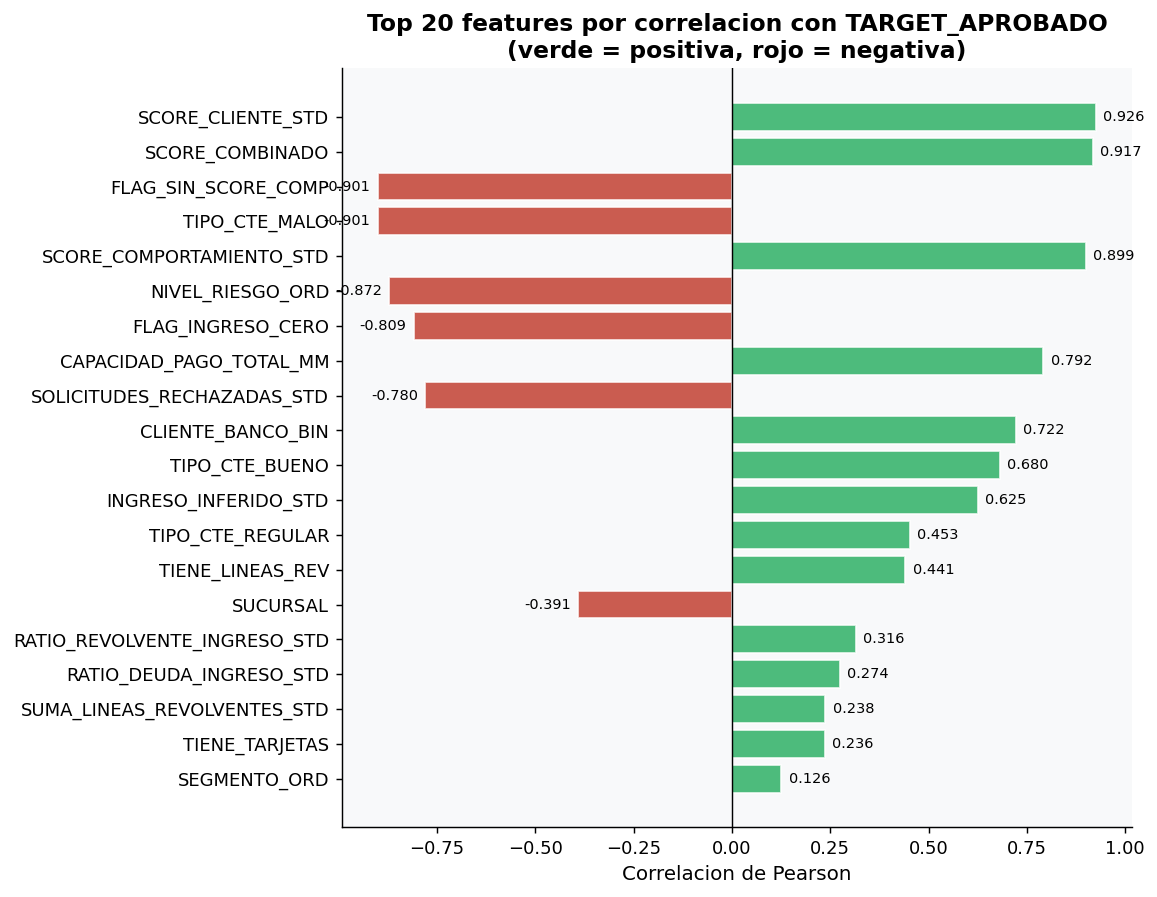

In [14]:
# ── Correlacion de features numericas con TARGET_APROBADO ───────────────────
num_feat_m1 = df_m1.select_dtypes(include=[np.number]).columns.tolist()
num_feat_m1 = [c for c in num_feat_m1 if c != "TARGET_APROBADO"]

corrs = df_m1[num_feat_m1 + ["TARGET_APROBADO"]].corr()["TARGET_APROBADO"].drop("TARGET_APROBADO")
corrs = corrs.sort_values(key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [RED if v < 0 else GREEN for v in corrs.values]
bars = ax.barh(corrs.index, corrs.values, color=colors, alpha=0.82, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in corrs.values], padding=4, fontsize=8)
ax.set_title("Top 20 features por correlacion con TARGET_APROBADO\n(verde = positiva, rojo = negativa)",
             fontweight="bold")
ax.set_xlabel("Correlacion de Pearson")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/03_correlacion_target.png", bbox_inches="tight")
plt.show()


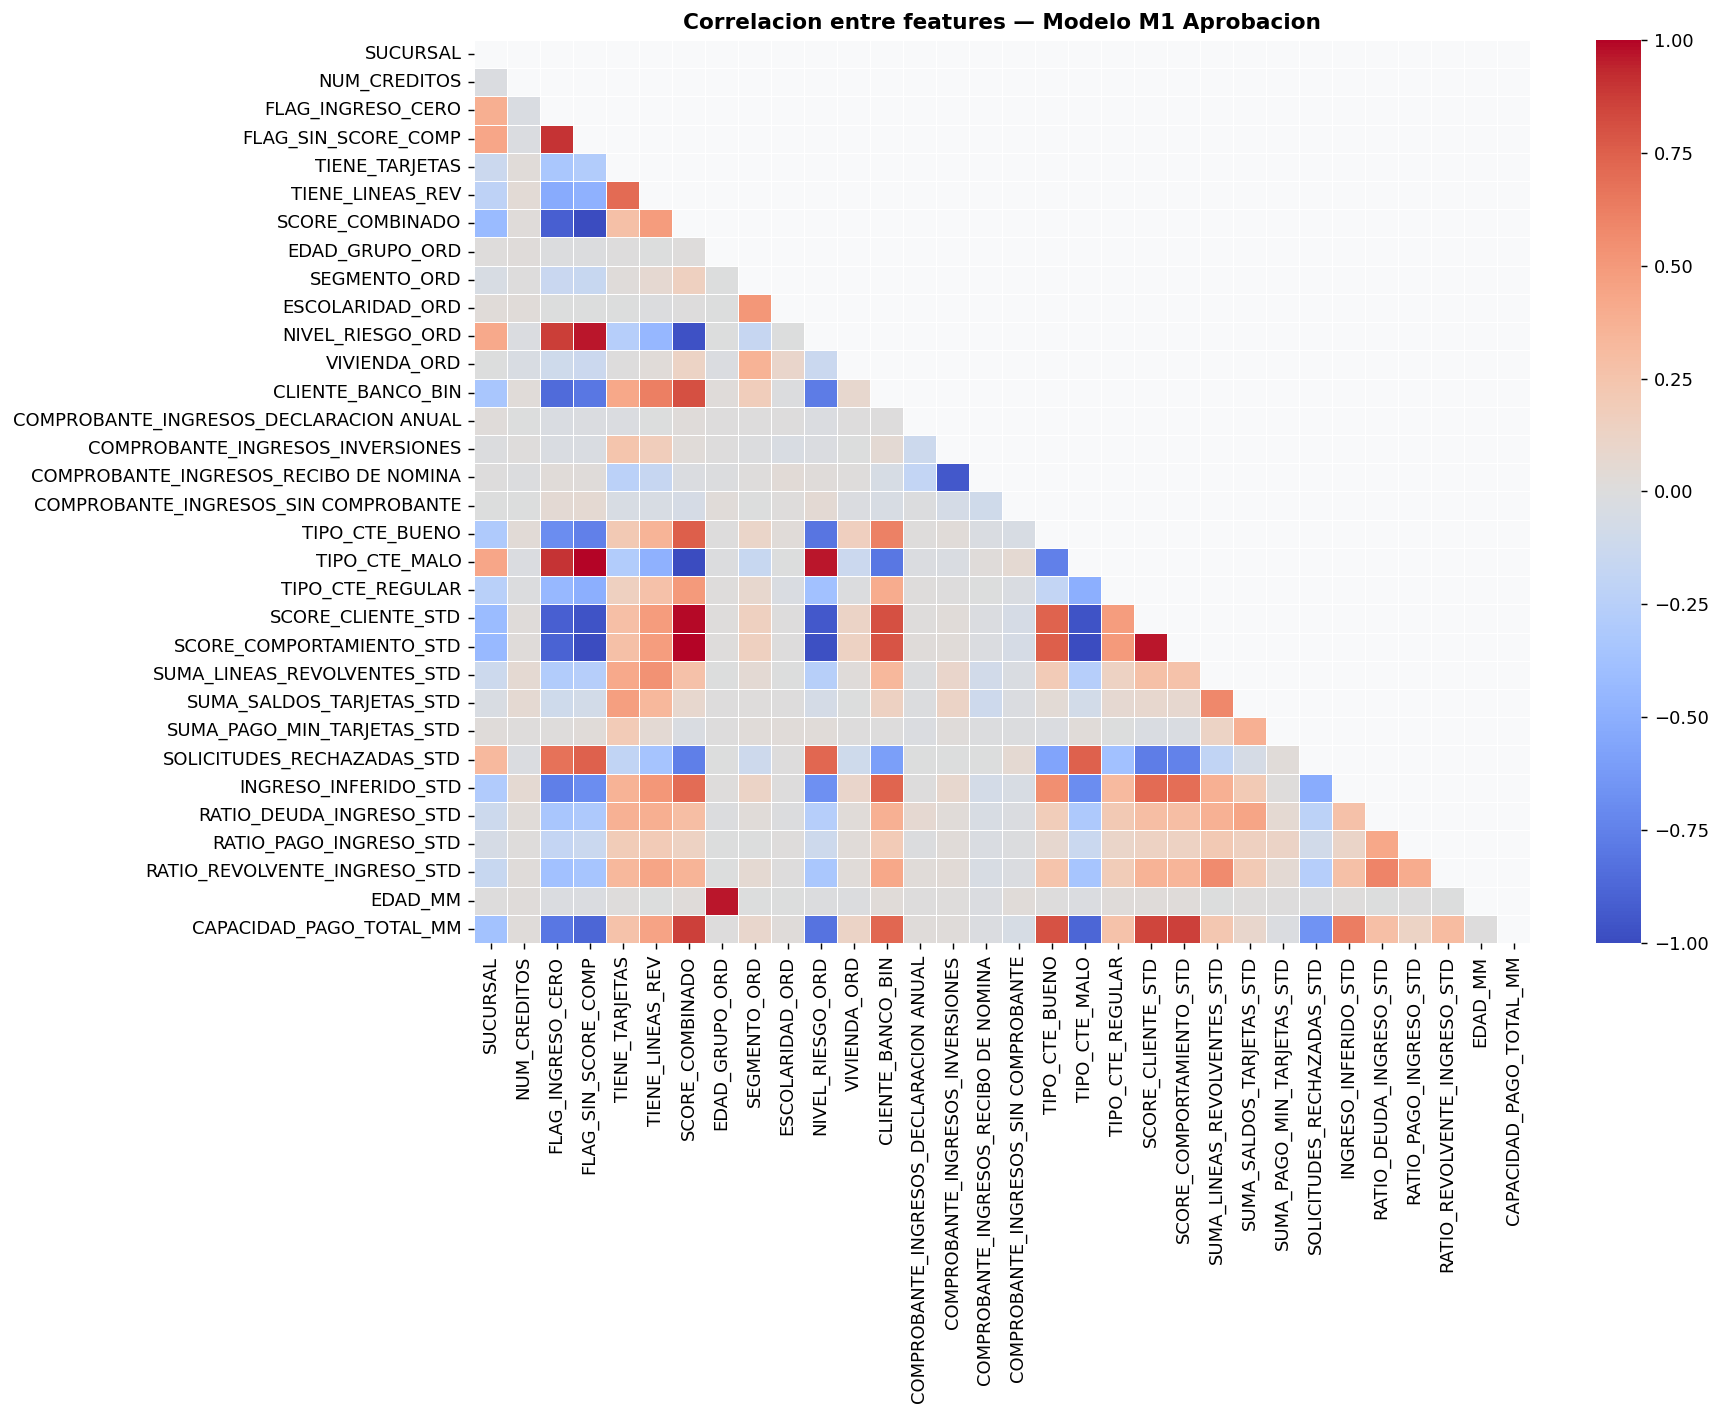

In [15]:
# ── Heatmap de correlacion entre features del M1 ────────────────────────────
corr_m1 = df_m1[num_feat_m1].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_m1, dtype=bool))
sns.heatmap(
    corr_m1, mask=mask, annot=False, cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="white", ax=ax
)
ax.set_title("Correlacion entre features — Modelo M1 Aprobacion",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/03_heatmap_features_m1.png", bbox_inches="tight")
plt.show()


---
## Resumen 

| Transformacion | Detalle |
|---|---|
| Targets definidos | `TARGET_APROBADO` (binario) y `TARGET_PRODUCTO` (multiclase 0/1/2) |
| Flags creados | 4 variables binarias capturando ausencia de informacion como señal |
| Ratios financieros | 4 ratios + score combinado + grupo de edad |
| Encoding ordinal | 5 variables con orden natural preservado |
| Encoding binario | `CLIENTE_BANCO_BIN` |
| One-hot encoding | `COMPROBANTE_INGRESOS` (4) + `TIPO_CTE` (3) = 7 dummies |
| Leakage documentado | 9 variables marcadas como excluidas de M1 |
| StandardScaler | 10 variables — guardado en `models/scaler_standard.pkl` |
| MinMaxScaler | 3 variables — guardado en `models/scaler_minmax.pkl` |
| Datasets generados | `banco_features.csv`, `features_modelo_aprobacion.csv`, `features_modelo_producto.csv` |
